# 2022 NHTS: observed household-vehicle trip chains

This notebook reconstructs chronological **candidate** vehicle movements from
person-trip records. It uses the same population and conflict rule as
`02_travel_eda.ipynb`. It does not estimate EV energy, charging, SOC, or grid load.

Source definitions: the local 2022 NextGen NHTS User Guide (travel-day definition,
p. 4; vehicle-trip filter, p. 26; person-trip grain, p. 29; weights, §7.2) and
Public Use Codebook v2.0.1 (Trip variables, pp. 34–47), both in
`data/raw/nhts_2022/docs/`. See `docs/methodology/nhts_variable_mapping.md`.
The public `TDAYDATE` is **YYYYMM**, so the 04:00–04:00 survey-day clock below
is an ordering coordinate, **not** an invented calendar timestamp.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

root = Path.cwd().resolve()
if not (root / "data" / "raw" / "nhts_2022").exists():
    root = root.parent
raw = root / "data" / "raw" / "nhts_2022"
figure_dir = root / "outputs" / "figures" / "trip_chains"
interim_dir = root / "data" / "interim"
figure_dir.mkdir(parents=True, exist_ok=True)
interim_dir.mkdir(parents=True, exist_ok=True)
trip = pd.read_csv(raw / "tripv2pub.csv", dtype="string", keep_default_na=False)
vehicle = pd.read_csv(raw / "vehv2pub.csv", dtype="string", keep_default_na=False)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
BLUE, ORANGE, GREEN, PURPLE, GREY = "#2463a6", "#dd7e27", "#287d69", "#7757a5", "#758393"

def hhmm_minutes(series):
    text = series.astype("string")
    hour = pd.to_numeric(text.str[:2], errors="coerce")
    minute = pd.to_numeric(text.str[2:4], errors="coerce")
    valid = text.str.fullmatch(r"\d{4}").fillna(False) & hour.between(0, 23) & minute.between(0, 59)
    return (60 * hour + minute).where(valid).astype("Float64")

def clock(value):
    minute = int(value) % 1440
    return f"{minute // 60:02d}:{minute % 60:02d}"

def save_show(fig, name):
    fig.tight_layout()
    path = figure_dir / name
    fig.savefig(path, dpi=190, bbox_inches="tight")
    plt.show()
    return path



## 1. Reproduce the clean candidate sample exactly

The official TRIP table is person-trip data, not a vehicle-movement table.
We require household vehicle (`TRPHHVEH=01`), driver (`DRVR_FLG=01`), a rostered
`VEHCASEID`, and documented privately operated modes `01/02/03/04/06/07`.
As in notebook 02, valid records need HHMM clocks, nonnegative trip minutes/miles,
and clock duration matching `TRVLCMIN` modulo 24 hours. Whole vehicle-days with
duplicate starts or interval overlap are held out; **no rows are deduplicated**.

In [2]:
POV_MODES = {"01", "02", "03", "04", "06", "07"}
household_vehicle = trip.loc[trip.TRPHHVEH.eq("01")].copy()
all_drivers = trip.loc[trip.DRVR_FLG.eq("01")].copy()
household_driver = household_vehicle.loc[household_vehicle.DRVR_FLG.eq("01")].copy()
candidate = household_driver.loc[
    household_driver.VEHCASEID.ne("-1") &
    household_driver.VEHCASEID.isin(vehicle.VEHCASEID) &
    household_driver.TRPTRANS.isin(POV_MODES)
].copy()
candidate["start_min"] = hhmm_minutes(candidate.STRTTIME)
candidate["end_min"] = hhmm_minutes(candidate.ENDTIME)
for col in ["TRVLCMIN", "TRPMILES", "DWELTIME", "WTTRDFIN", "WTTRDFIN5D", "WTTRDFIN2D"]:
    candidate[col + "_num"] = pd.to_numeric(candidate[col], errors="coerce")
candidate["crosses_midnight"] = candidate.end_min < candidate.start_min
candidate["clock_duration"] = (candidate.end_min - candidate.start_min) % 1440
candidate["valid_measures"] = (
    candidate.start_min.notna() & candidate.end_min.notna() &
    candidate.TRVLCMIN_num.ge(0) & candidate.TRPMILES_num.ge(0) &
    candidate.clock_duration.eq(candidate.TRVLCMIN_num)
)
valid = candidate.loc[candidate.valid_measures.fillna(False)].copy()
invalid = candidate.loc[~candidate.valid_measures.fillna(False)].copy()
# Survey day is 04:00 to 04:00 next day; 00:00–03:59 starts are next-day clock positions.
valid["survey_start_min"] = valid.start_min.where(valid.start_min >= 240, valid.start_min + 1440)
valid["survey_end_min"] = valid.survey_start_min + valid.TRVLCMIN_num
start_size = valid.groupby(["VEHCASEID", "STRTTIME"]).TDCASEID.transform("size")
same_start = valid.loc[start_size > 1]
same_start_ids = set(same_start.VEHCASEID)
unique_start = valid.loc[~valid.VEHCASEID.isin(same_start_ids)].copy()
unique_start = unique_start.sort_values(["VEHCASEID", "survey_start_min", "survey_end_min"])
running_end = unique_start.groupby("VEHCASEID").survey_end_min.cummax()
unique_start["prior_end"] = running_end.groupby(unique_start.VEHCASEID).shift()
overlap = unique_start.loc[unique_start.survey_start_min < unique_start.prior_end]
overlap_ids = set(overlap.VEHCASEID)
conflict_ids = same_start_ids | overlap_ids
held_out = valid.loc[valid.VEHCASEID.isin(conflict_ids)].copy()
analysis = valid.loc[~valid.VEHCASEID.isin(conflict_ids)].copy()
analysis = analysis.sort_values(["VEHCASEID", "survey_start_min", "survey_end_min"])
exact_pairs = valid.groupby(["VEHCASEID", "STRTTIME", "ENDTIME", "TRPMILES"]).size()

assert (len(trip), len(candidate), len(valid), len(analysis), analysis.VEHCASEID.nunique()) == (31074, 20067, 20058, 19673, 6874)
assert len(conflict_ids) == 69 and len(invalid) == 9
flow = pd.DataFrame([
    ("All Trip person trips", len(trip)),
    ("Household-vehicle person trips", len(household_vehicle)),
    ("Driver person trips (all vehicles)", len(all_drivers)),
    ("Household-vehicle driver rows", len(household_driver)),
    ("Rostered ID and documented POV mode", len(candidate)),
    ("Valid clocks, duration, distance", len(valid)),
    ("After deduplication (none done)", len(valid)),
    ("Conflict-free candidate legs", len(analysis)),
], columns=["Stage", "Rows"])
display(flow)
display(pd.Series({
    "candidate vehicles": candidate.VEHCASEID.nunique(),
    "invalid candidate records held aside": len(invalid),
    "same-start vehicle-days held": len(same_start_ids),
    "other overlapping vehicle-days held": len(overlap_ids),
    "total conflicted vehicle-days held": len(conflict_ids),
    "valid trip rows on held-out vehicle-days": len(held_out),
    "final vehicles/chains": analysis.VEHCASEID.nunique(),
}, name="Audit count"))



,Stage,Rows
0,All Trip person trips,31074
1,Household-vehicle person trips,26294
2,Driver person trips (all vehicles),20490
3,Household-vehicle driver rows,20067
4,Rostered ID and documented POV mode,20067
5,"Valid clocks, duration, distance",20058
6,After deduplication (none done),20058
7,Conflict-free candidate legs,19673


candidate vehicles                          6943
invalid candidate records held aside           9
same-start vehicle-days held                  59
other overlapping vehicle-days held           10
total conflicted vehicle-days held            69
valid trip rows on held-out vehicle-days     385
final vehicles/chains                       6874
Name: Audit count, dtype: int64

## 2. Diagnose conflicting driver reports

`TDCASEID` identifies a person-trip record, not a physical movement. The duplicate
groups below are audited on identifiers, clocks, miles, purposes, reported driver,
and trip weight. Agreement on a subset of fields is not proof that two reports
are duplicates; disagreement prevents a safe person-trip deduplication rule.

In [3]:
same_start_groups = (same_start.groupby(["VEHCASEID", "STRTTIME"])
    .agg(rows=("TDCASEID", "size"), persons=("PERSONID", "nunique"),
         ends=("ENDTIME", "nunique"), miles=("TRPMILES", "nunique"),
         origins=("WHYFROM", "nunique"), destinations=("WHYTO", "nunique"),
         reported_drivers=("WHODROVE", "nunique"), weights=("WTTRDFIN", "nunique")))
display(pd.Series({
    "same-vehicle/start groups": len(same_start_groups),
    "same-start driver rows": len(same_start),
    "groups with different persons": int(same_start_groups.persons.gt(1).sum()),
    "groups with different end times": int(same_start_groups.ends.gt(1).sum()),
    "groups with different miles": int(same_start_groups.miles.gt(1).sum()),
    "groups with different origin purposes": int(same_start_groups.origins.gt(1).sum()),
    "groups with different destination purposes": int(same_start_groups.destinations.gt(1).sum()),
    "groups with different reported drivers": int(same_start_groups.reported_drivers.gt(1).sum()),
    "groups with different trip weights": int(same_start_groups.weights.gt(1).sum()),
    "exact vehicle/start/end/miles groups": int(exact_pairs.gt(1).sum()),
    "additional overlapping rows": len(overlap),
}, name="Conflict diagnostic"))
display(same_start_groups.head(8))
display(overlap[["HOUSEID", "VEHCASEID", "TDCASEID", "PERSONID", "STRTTIME", "ENDTIME",
                 "survey_start_min", "survey_end_min", "prior_end", "TRPMILES"]].head(12))
display(Markdown(
    "Even identical start/end/miles can be two distinct **person** reports of one possible "
    "movement, while differing end times, miles, purposes, driver identities, or weights "
    "leave some groups unresolved. No official field in these public records is a unique "
    "vehicle-movement ID. All 69 affected vehicle-days remain excluded; nine measurement-invalid "
    "candidate rows remain separately auditable."
))



same-vehicle/start groups                      92
same-start driver rows                        184
groups with different persons                  92
groups with different end times                27
groups with different miles                    19
groups with different origin purposes           9
groups with different destination purposes     17
groups with different reported drivers         92
groups with different trip weights             92
exact vehicle/start/end/miles groups           57
additional overlapping rows                    14
Name: Conflict diagnostic, dtype: int64

rows  persons  ends  miles  origins  destinations  \
VEHCASEID    STRTTIME                                                      
900001315801 1300         2        2     2      2        2             2   
900001445401 0615         2        2     1      1        1             2   
             1815         2        2     2      2        2             1   
900001466601 0830         2        2     1      1        1             1   
             1130         2        2     2      1        1             1   
900001729302 1900         2        2     2      1        1             1   
900001841501 1700         2        2     2      2        1             1   
900004797101 2250         2        2     1      1        1             1   

                       reported_drivers  weights  
VEHCASEID    STRTTIME                             
900001315801 1300                     2        2  
900001445401 0615                     2        2  
             1815                     2        2  
900001466601 0830                     2        2  
             1130                     2        2  
900001729302 1900                     2        2  
900001841501 1700                     2        2  
900004797101 2250                     2        2

,HOUSEID,VEHCASEID,TDCASEID,PERSONID,STRTTIME,ENDTIME,survey_start_min,survey_end_min,prior_end,TRPMILES
3210,9000047735,900004773501,90000477350101,01,0743,0748,463.0,468.0,480.0,1.52144188937228
5198,9000052396,900005239601,90000523960106,01,0102,0150,1502.0,1550.0,2160.0,11.969546302051
5199,9000052396,900005239601,90000523960107,01,0155,0210,1555.0,1570.0,2160.0,11.7209446861405
5960,9000054317,900005431702,90000543170102,01,1805,1830,1085.0,1110.0,1110.0,11.0627719080174
7505,9000071747,900007174703,90000717470101,01,0720,0724,440.0,444.0,453.0,1.31199502796768
8925,9000074837,900007483701,90000748370201,02,1250,1319,770.0,799.0,780.0,0.566190180236172
8927,9000074837,900007483701,90000748370203,02,1344,1420,824.0,860.0,843.0,19.0254816656308
8923,9000074837,900007483701,90000748370103,01,1532,1600,932.0,960.0,960.0,20.0901180857676
8924,9000074837,900007483701,90000748370104,01,1632,1700,992.0,1020.0,1020.0,3.93784959602237
10131,9000077004,900007700401,90000770040101,01,0925,1000,565.0,600.0,570.0,21.7973896830329


Even identical start/end/miles can be two distinct **person** reports of one possible movement, while differing end times, miles, purposes, driver identities, or weights leave some groups unresolved. No official field in these public records is a unique vehicle-movement ID. All 69 affected vehicle-days remain excluded; nine measurement-invalid candidate rows remain separately auditable.

## 3. Chronological leg representation

Times are HHMM clocks converted to minutes. A trip starting before 04:00 is placed
at the end of the NHTS travel day; arrival is start plus reported minutes, so a
midnight crossing stays chronological. `vehicle_leg_index` is *our* within-vehicle
ordering, distinct from NHTS `SEQ_TRIPID` (a person-trip sequence). `TDAYDATE` is
retained as its reported month only. The trip weight `WTTRDFIN` is retained for
traceability, **not** used as a vehicle-day or parking-interval weight.

In [4]:
PURPOSE_LABELS = {
    "01":"Regular activities at home", "02":"Work from home (paid)",
    "03":"Work at a non-home location",
    "04":"Work activity: drop off/pick up", "05":"Other work-related activities",
    "06":"Attend school as a student", "07":"Attend childcare/adult care",
    "08":"Volunteer activities", "09":"Change transportation type",
    "10":"Personal drop off/pick up", "11":"Health care visit",
    "12":"Buy meals", "13":"Shop/buy/pick up/return goods",
    "14":"Other family/personal errands", "15":"Recreational activities",
    "16":"Exercise", "17":"Visit friends/relatives",
    "18":"Rest/relaxation/vacation", "19":"Religious/community activities",
    "97":"Something else (specify)",
}
MODE_LABELS = {"01":"Car", "02":"Van", "03":"SUV/crossover",
               "04":"Pickup", "06":"RV", "07":"Motorcycle"}
def purpose_group(code):
    if code in {"01", "02"}: return "Home"
    if code == "03": return "Work"
    if code in {"13", "14"}: return "Shopping/errands"
    if code in {"15", "16", "17", "18"}: return "Social/recreation"
    if code in PURPOSE_LABELS: return "Other"
    return "Unknown"

assert set(analysis.WHYTO).issubset(PURPOSE_LABELS)
legs = analysis.copy()
legs["vehicle_leg_index"] = legs.groupby("VEHCASEID").cumcount() + 1
legs["trip_duration_min"] = legs.TRVLCMIN_num.astype(float)
legs["trip_distance_miles"] = legs.TRPMILES_num.astype(float)
legs["origin_group"] = legs.WHYFROM.map(purpose_group)
legs["destination_group"] = legs.WHYTO.map(purpose_group)
legs["travel_mode_label"] = legs.TRPTRANS.map(MODE_LABELS)
for field in ["TDCASEID", "PERSONID", "WHYFROM", "survey_start_min"]:
    legs["next_" + field] = legs.groupby("VEHCASEID")[field].shift(-1)
has_next = legs.next_TDCASEID.notna()
known = legs.WHYTO.isin(PURPOSE_LABELS) & legs.next_WHYFROM.isin(PURPOSE_LABELS)
equal_purpose = legs.WHYTO.eq(legs.next_WHYFROM).fillna(False)
legs["continuity_to_next"] = np.where(~has_next, "no_next",
    np.where(~known, "unknown", np.where(equal_purpose, "match", "mismatch")))
assert legs.TDCASEID.is_unique
assert (legs.groupby("VEHCASEID").vehicle_leg_index.min() == 1).all()
display(legs[["HOUSEID", "VEHCASEID", "TDCASEID", "vehicle_leg_index",
              "STRTTIME", "ENDTIME", "survey_start_min", "survey_end_min",
              "trip_duration_min", "trip_distance_miles", "WHYFROM", "WHYTO",
              "TRPTRANS", "WTTRDFIN", "continuity_to_next"]].head(8))



,HOUSEID,VEHCASEID,TDCASEID,vehicle_leg_index,STRTTIME,ENDTIME,survey_start_min,survey_end_min,trip_duration_min,trip_distance_miles,WHYFROM,WHYTO,TRPTRANS,WTTRDFIN,continuity_to_next
0,9000013002,900001300201,90000130020101,1,1435,1450,875.0,890.0,15.0,3.902424,01,15,03,1608361.95907888,match
1,9000013002,900001300201,90000130020102,2,1605,1615,965.0,975.0,10.0,3.902424,15,01,03,1608361.95907888,no_next
2,9000013002,900001300202,90000130020201,1,0700,0730,420.0,450.0,30.0,17.077067,01,12,03,2208973.05782135,match
3,9000013002,900001300202,90000130020202,2,0740,0750,460.0,470.0,10.0,4.748291,12,12,03,2208973.05782135,match
4,9000013002,900001300202,90000130020203,3,0800,0830,480.0,510.0,30.0,14.098819,12,01,03,2208973.05782135,no_next
10,9000013016,900001301601,90000130160201,1,0930,0940,570.0,580.0,10.0,0.911746,01,11,01,1231230.34794065,match
11,9000013016,900001301601,90000130160202,2,1400,1415,840.0,855.0,15.0,4.598508,11,14,01,1326753.07878427,match
12,9000013016,900001301601,90000130160203,3,1600,1630,960.0,990.0,30.0,5.423244,14,01,01,1231230.34794065,no_next


## 4. Purpose continuity: diagnostic, not an automatic repair

For each consecutive vehicle leg, compare prior `WHYTO` with next `WHYFROM`.
The User Guide (p. 25) says `WHYFROM` is derived from preceding `WHYTO` for all
but a person's first trip. Thus a same-person match is **partly mechanical**,
not independent proof of physical vehicle continuity. Cross-person matches are
informative but still only reported activities, not coordinates. Unknown or
mismatched transitions stay flagged; neither is repaired.

In [5]:
pairs = legs.loc[has_next].copy()
pair_counts = (pairs.groupby("VEHCASEID").continuity_to_next
               .value_counts().unstack(fill_value=0))
for status in ["match", "mismatch", "unknown"]:
    if status not in pair_counts: pair_counts[status] = 0
vehicle_day = legs.groupby("VEHCASEID").agg(
    HOUSEID=("HOUSEID", "first"), trips=("TDCASEID", "size"),
    observed_miles=("trip_distance_miles", "sum"),
    first_departure_min=("survey_start_min", "first"),
    final_arrival_min=("survey_end_min", "last"),
    first_origin=("WHYFROM", "first"), last_destination=("WHYTO", "last"),
    drivers=("PERSONID", "nunique"),
).join(pair_counts[["match", "mismatch", "unknown"]], how="left").fillna(
    {"match":0, "mismatch":0, "unknown":0})
vehicle_day["chain_status"] = np.select(
    [vehicle_day.trips.eq(1), vehicle_day.mismatch.gt(0), vehicle_day.unknown.gt(0)],
    ["single_leg", "mismatch", "unknown"], default="complete")
vehicle_day["begins_home"] = vehicle_day.first_origin.isin({"01", "02"})
vehicle_day["ends_home"] = vehicle_day.last_destination.isin({"01", "02"})
legs["chain_status"] = legs.VEHCASEID.map(vehicle_day.chain_status)
legs["begins_home"] = legs.VEHCASEID.map(vehicle_day.begins_home)
legs["ends_home"] = legs.VEHCASEID.map(vehicle_day.ends_home)
pairs["chain_status"] = pairs.VEHCASEID.map(vehicle_day.chain_status)

multi = vehicle_day.loc[vehicle_day.trips.gt(1)]
status_counts = vehicle_day.chain_status.value_counts()
display(pd.DataFrame({
    "vehicles/chains": status_counts.reindex(["complete", "mismatch", "unknown", "single_leg"], fill_value=0),
    "share of all vehicles (%)": (100 * status_counts / len(vehicle_day)).reindex(
        ["complete", "mismatch", "unknown", "single_leg"], fill_value=0).round(1),
}))
display(pd.Series({
    "multi-leg vehicles": len(multi),
    "multi-leg with complete purpose continuity": int(multi.chain_status.eq("complete").sum()),
    "complete share of multi-leg (%)": 100 * multi.chain_status.eq("complete").mean(),
    "multi-leg with one or more mismatches": int(multi.mismatch.gt(0).sum()),
    "pairwise matches": int(pairs.continuity_to_next.eq("match").sum()),
    "pairwise mismatches": int(pairs.continuity_to_next.eq("mismatch").sum()),
    "pairwise unknowns": int(pairs.continuity_to_next.eq("unknown").sum()),
    "pairwise driver changes": int(pairs.PERSONID.ne(pairs.next_PERSONID).sum()),
}, name="Continuity audit").round(1))
discontinuities = pairs.loc[pairs.continuity_to_next.eq("mismatch")].copy()
discontinuities["reported arrival"] = discontinuities.WHYTO.map(PURPOSE_LABELS)
discontinuities["next reported origin"] = discontinuities.next_WHYFROM.map(PURPOSE_LABELS)
display((discontinuities.groupby(["reported arrival", "next reported origin"])
         .size().sort_values(ascending=False).head(10).rename("transitions").to_frame()))



,vehicles/chains,share of all vehicles (%)
chain_status,,
complete,6227,90.6
mismatch,181,2.6
unknown,2,0.0
single_leg,464,6.8


multi-leg vehicles                             6410.0
multi-leg with complete purpose continuity     6227.0
complete share of multi-leg (%)                  97.1
multi-leg with one or more mismatches           181.0
pairwise matches                              12582.0
pairwise mismatches                             215.0
pairwise unknowns                                 2.0
pairwise driver changes                         379.0
Name: Continuity audit, dtype: float64

,,transitions
reported arrival,next reported origin,
Regular activities at home,Work at a non-home location,15
Work from home (paid),Regular activities at home,15
Personal drop off/pick up,Regular activities at home,15
Work at a non-home location,Regular activities at home,13
Regular activities at home,Exercise,8
Shop/buy/pick up/return goods,Regular activities at home,8
Regular activities at home,Work from home (paid),7
Work at a non-home location,Work activity: drop off/pick up,6
Regular activities at home,Shop/buy/pick up/return goods,6


## 5. Derived observed inter-trip intervals and `DWELTIME`

For consecutive, non-overlapping legs of one vehicle, the observed gap starts
at leg *i* arrival and ends at leg *i+1* departure. It is associated with leg
*i*'s destination. We call it a **candidate parking interval**, not a measured
stationary period. The presentation analysis uses only intervals from entire
purpose-continuous multi-leg chains that lie inside 04:00–04:00. Other intervals
remain in the interim CSV with flags. Final-trip and pre-first-trip intervals
are undefined; no overnight duration is manufactured.

`DWELTIME` is officially “Time at Destination (minutes)” for the *person trip*.
It need not equal the same vehicle's gap, especially if a different household
person next drives, and is missing/encoded for many trip records.

In [6]:
parking = pairs[["HOUSEID", "VEHCASEID", "TDCASEID", "next_TDCASEID", "PERSONID",
                 "next_PERSONID", "WHYTO", "next_WHYFROM", "destination_group",
                 "survey_end_min", "next_survey_start_min", "DWELTIME", "DWELTIME_num",
                 "continuity_to_next", "chain_status"]].copy()
parking = parking.rename(columns={"survey_end_min":"parking_start_min",
                                  "next_survey_start_min":"parking_end_min"})
parking["parking_duration_min"] = (parking.parking_end_min - parking.parking_start_min).astype(float)
parking["parking_start_clock"] = parking.parking_start_min.map(clock)
parking["parking_end_clock"] = parking.parking_end_min.map(clock)
parking["same_driver"] = parking.PERSONID.eq(parking.next_PERSONID)
parking["within_survey_window"] = (parking.parking_start_min.ge(240) &
                                   parking.parking_end_min.le(1680))
parking["analysis_eligible"] = (parking.chain_status.eq("complete") &
                                parking.within_survey_window)
parking["dwell_valid_min"] = parking.DWELTIME_num.where(parking.DWELTIME_num.ge(0))
parking["gap_minus_dwell_min"] = parking.parking_duration_min - parking.dwell_valid_min
assert parking.parking_duration_min.ge(0).all()
assert len(parking) == len(legs) - len(vehicle_day)
eligible = parking.loc[parking.analysis_eligible].copy()
display(pd.Series({
    "all consecutive-leg gaps": len(parking),
    "gaps on complete-continuity chains": int(parking.chain_status.eq("complete").sum()),
    "gaps inside survey-day window": int(parking.within_survey_window.sum()),
    "eligible inferred parking intervals": len(eligible),
    "eligible zero-minute gaps": int(eligible.parking_duration_min.eq(0).sum()),
    "eligible intervals with recorded DWELTIME": int(eligible.dwell_valid_min.notna().sum()),
}, name="Interval count"))
display(parking[["VEHCASEID", "TDCASEID", "next_TDCASEID", "destination_group",
                 "parking_start_clock", "parking_end_clock", "parking_duration_min",
                 "continuity_to_next", "chain_status", "analysis_eligible"]].head(8))



all consecutive-leg gaps                     12799
gaps on complete-continuity chains           12159
gaps inside survey-day window                12799
eligible inferred parking intervals          12159
eligible zero-minute gaps                      600
eligible intervals with recorded DWELTIME    12088
Name: Interval count, dtype: int64

,VEHCASEID,TDCASEID,next_TDCASEID,destination_group,parking_start_clock,parking_end_clock,parking_duration_min,continuity_to_next,chain_status,analysis_eligible
0,900001300201,90000130020101,90000130020102,Social/recreation,14:50,16:05,75.0,match,complete,True
2,900001300202,90000130020201,90000130020202,Other,07:30,07:40,10.0,match,complete,True
3,900001300202,90000130020202,90000130020203,Other,07:50,08:00,10.0,match,complete,True
10,900001301601,90000130160201,90000130160202,Other,09:40,14:00,260.0,match,complete,True
11,900001301601,90000130160202,90000130160203,Shopping/errands,14:15,16:00,105.0,match,complete,True
13,900001303901,90000130390101,90000130390102,Shopping/errands,17:10,18:00,50.0,match,complete,True
15,900001304201,90000130420101,90000130420102,Social/recreation,15:30,16:30,60.0,match,complete,True
24,900001304501,90000130450101,90000130450102,Other,13:50,13:50,0.0,match,complete,True


In [7]:
both = eligible.loc[eligible.dwell_valid_min.notna()].copy()
def dwell_comparison(frame):
    if frame.empty:
        return pd.Series({"pairs":0, "median signed difference (min)":np.nan,
                          "median absolute difference (min)":np.nan,
                          "exact match (%)":np.nan, "within 5 min (%)":np.nan})
    diff = frame.gap_minus_dwell_min.astype(float)
    return pd.Series({"pairs":len(frame), "median signed difference (min)":diff.median(),
                      "median absolute difference (min)":diff.abs().median(),
                      "exact match (%)":100*diff.eq(0).mean(),
                      "within 5 min (%)":100*diff.abs().le(5).mean()})
comparison = pd.DataFrame({
    "All eligible pairs":dwell_comparison(both),
    "Same respondent drives next":dwell_comparison(both.loc[both.same_driver]),
    "Different respondent drives next":dwell_comparison(both.loc[~both.same_driver]),
}).T
display(comparison.round(1))
display(Markdown(
    "A close match is a sanity check, not validation of actual parking: person dwell "
    "may be mechanically related to that person's next trip, and the vehicle may have "
    "unreported use or have changed driver. Longer gaps are therefore possible "
    "*opportunities*, not observed charging windows."
))



,pairs,median signed difference (min),median absolute difference (min),exact match (%),within 5 min (%)
All eligible pairs,12088.0,0.0,0.0,98.9,98.9
Same respondent drives next,11927.0,0.0,0.0,99.2,99.2
Different respondent drives next,161.0,0.0,0.0,80.1,81.4


A close match is a sanity check, not validation of actual parking: person dwell may be mechanically related to that person's next trip, and the vehicle may have unreported use or have changed driver. Longer gaps are therefore possible *opportunities*, not observed charging windows.

## 6. Where and when candidate stationary windows occur

Destination group mapping uses official `WHYTO` codes: Home 01/02; non-home Work
03; Shopping/errands 13/14; Social/recreation 15–18. “Other” contains the remaining
documented purposes (including 04/05 work-related other) and is intentionally
heterogeneous. Statistics below are **raw sample intervals**, not nationally
weighted estimates: `WTTRDFIN` is a *trip* weight, not a derived vehicle-gap weight.

,intervals,median (h),p25 (h),p75 (h),p90 (h),>1 h (%),>2 h (%),>4 h (%)
destination_group,,,,,,,,
Home,1351.0,2.2,0.9,4.4,7.2,69.8,52.6,28.3
Work,2198.0,8.2,5.3,9.2,10.4,95.5,91.9,82.0
Shopping/errands,3287.0,0.5,0.2,0.8,1.4,18.0,4.3,1.2
Social/recreation,1481.0,1.8,1.0,3.0,4.5,74.9,43.6,14.4
Other,3842.0,0.6,0.2,1.5,3.5,35.7,18.6,8.6


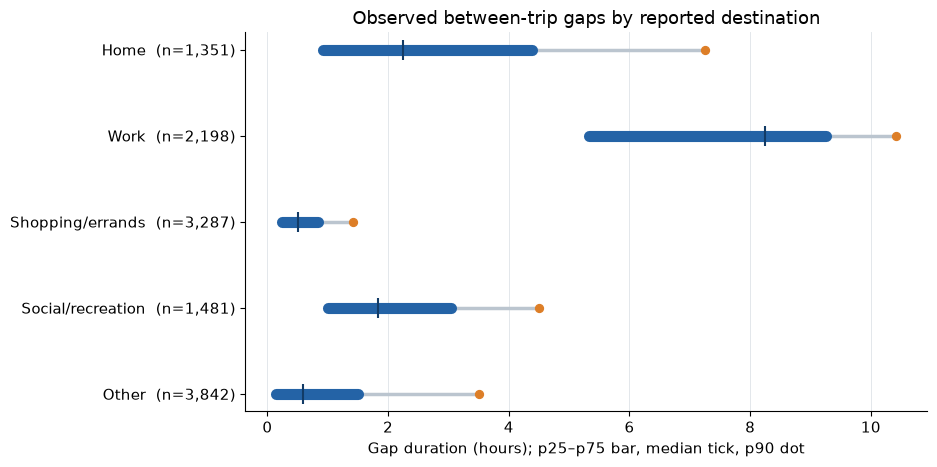

- Home gaps: median **2.2 h**; **28.3%** exceed four hours.
- Work gaps: median **8.2 h**; **82.0%** exceed four hours. These are observed inter-trip gaps, not confirmed uninterrupted parking or charging.

In [8]:
dest_order = ["Home", "Work", "Shopping/errands", "Social/recreation", "Other"]
def parking_summary(g):
    duration = g.parking_duration_min.astype(float)
    return pd.Series({
        "intervals": len(g), "median (h)":duration.median()/60,
        "p25 (h)":duration.quantile(.25)/60, "p75 (h)":duration.quantile(.75)/60,
        "p90 (h)":duration.quantile(.9)/60,
        ">1 h (%)":100*duration.gt(60).mean(),
        ">2 h (%)":100*duration.gt(120).mean(),
        ">4 h (%)":100*duration.gt(240).mean(),
    })
parking_stats = eligible.groupby("destination_group").apply(parking_summary,
    include_groups=False).reindex(dest_order)
display(parking_stats.round(1))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
shown = parking_stats.dropna(subset=["intervals"])
positions = np.arange(len(shown))
for y, (_, row) in zip(positions, shown.iterrows()):
    ax.plot([row["p25 (h)"], row["p90 (h)"]], [y,y], color="#bbc5cf", lw=2.5)
    ax.plot([row["p25 (h)"], row["p75 (h)"]], [y,y], color=BLUE, lw=8,
            solid_capstyle="round")
    ax.scatter(row["median (h)"], y, marker="|", s=210, color="#123b66", zorder=3)
    ax.scatter(row["p90 (h)"], y, marker="o", s=32, color=ORANGE, zorder=3)
ax.set_yticks(positions, [f"{name}  (n={int(shown.loc[name,'intervals']):,})" for name in shown.index])
ax.invert_yaxis()
ax.set(title="Observed between-trip gaps by reported destination",
       xlabel="Gap duration (hours); p25–p75 bar, median tick, p90 dot")
ax.grid(axis="x", color="#e3e7eb", linewidth=.7)
fig_parking = save_show(fig, "01_parking_duration_by_destination.png")
display(Markdown(
    f"- Home gaps: median **{parking_stats.loc['Home','median (h)']:.1f} h**; "
    f"**{parking_stats.loc['Home','>4 h (%)']:.1f}%** exceed four hours.\n"
    f"- Work gaps: median **{parking_stats.loc['Work','median (h)']:.1f} h**; "
    f"**{parking_stats.loc['Work','>4 h (%)']:.1f}%** exceed four hours. "
    "These are observed inter-trip gaps, not confirmed uninterrupted parking or charging."
))



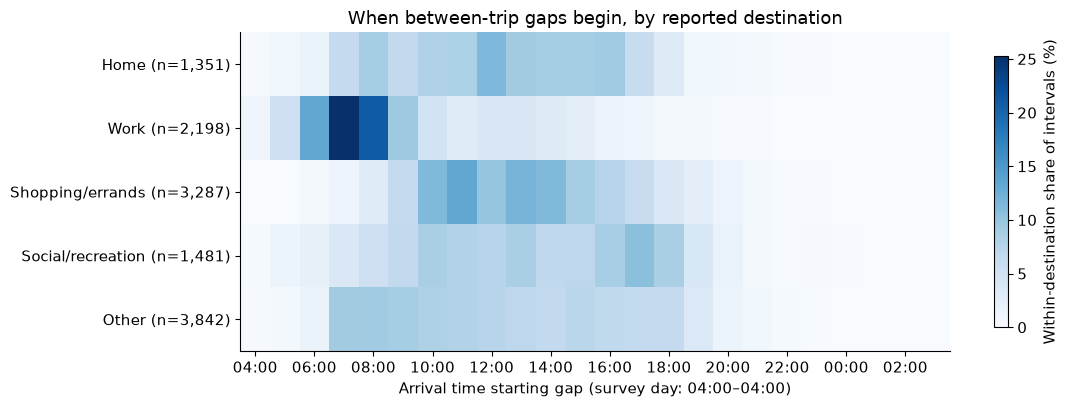

- The most common one-hour start bin is **12:00** for Home and **07:00** for Work; bins are normalized within each destination.
- These arrival patterns may guide later opportunity assumptions, but no plug-in or charger availability is observed here.

In [9]:
hour_edges = np.arange(240, 1681, 60)
matrix = []
for destination in dest_order:
    starts = eligible.loc[eligible.destination_group.eq(destination), "parking_start_min"].astype(float)
    counts = np.histogram(starts, bins=hour_edges)[0]
    matrix.append(100 * counts / len(starts) if len(starts) else np.zeros(24))
matrix = np.asarray(matrix)
fig, ax = plt.subplots(figsize=(11.5, 4.2))
im = ax.imshow(matrix, cmap="Blues", aspect="auto", vmin=0, vmax=max(1,matrix.max()))
ax.set_yticks(range(len(dest_order)),
              [f"{d} (n={int(parking_stats.loc[d,'intervals']):,})" for d in dest_order])
tick_positions = np.arange(0, 24, 2)
ax.set_xticks(tick_positions, [clock(hour_edges[i]) for i in tick_positions])
ax.set(title="When between-trip gaps begin, by reported destination",
       xlabel="Arrival time starting gap (survey day: 04:00–04:00)")
fig.colorbar(im, ax=ax, label="Within-destination share of intervals (%)", shrink=.85)
fig_start = save_show(fig, "02_parking_start_time_by_destination.png")
def peak_hour(destination):
    return clock(hour_edges[int(matrix[dest_order.index(destination)].argmax())])
display(Markdown(
    f"- The most common one-hour start bin is **{peak_hour('Home')}** for Home and "
    f"**{peak_hour('Work')}** for Work; bins are normalized within each destination.\n"
    "- These arrival patterns may guide later opportunity assumptions, but no plug-in "
    "or charger availability is observed here."
))



## 7. Home-boundary and observed vehicle-day patterns

A first leg with `WHYFROM` 01/02 is an *observed* departure from a reported home
activity; a last leg with `WHYTO` 01/02 is an *observed* return. A vehicle can have
an unobserved trip before/after the survey window. In particular, final-home
arrival is **not** an overnight parking duration.

,raw sample vehicles
all vehicles/chains,6874
first observed origin is home,6412
last observed destination is home,6273
both observed boundaries are home,5912
complete-continuity multi-leg chains with both home boundaries,5704


,observations,median clock,p25 clock,p75 clock
First departure from home,6412,09:30,07:30,12:30
Final observed return home,6273,16:45,14:10,18:45
Arrival at non-home work,2388,08:10,07:15,10:30
Departure from non-home work,2286,16:30,15:00,17:30


,trips,observed_miles
count,6874.0,6874.0
mean,2.9,31.8
std,1.6,59.9
min,1.0,0.0
25%,2.0,7.4
50%,2.0,16.6
75%,4.0,35.3
90%,5.0,65.3
max,22.0,1123.6


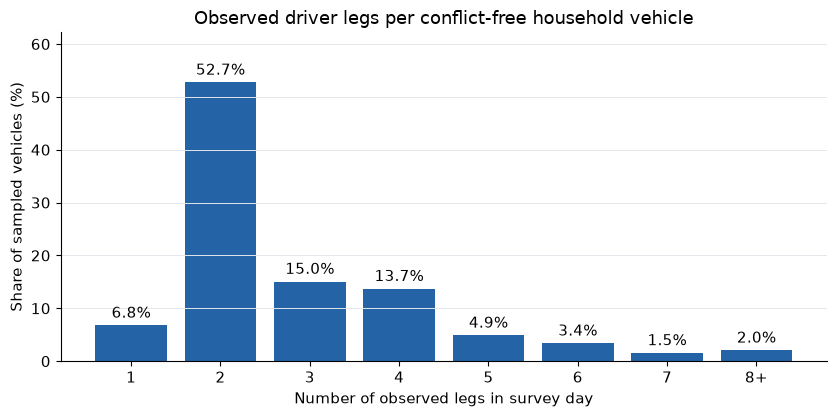

- The median sampled vehicle has **2** observed driver legs and **16.6 miles** of observed travel.
- The count excludes held-out conflicts and may miss unreported/unsampled movements; it is not a national vehicle-day estimate.

In [10]:
boundary = pd.Series({
    "all vehicles/chains":len(vehicle_day),
    "first observed origin is home":int(vehicle_day.begins_home.sum()),
    "last observed destination is home":int(vehicle_day.ends_home.sum()),
    "both observed boundaries are home":int((vehicle_day.begins_home & vehicle_day.ends_home).sum()),
    "complete-continuity multi-leg chains with both home boundaries":int(
        (vehicle_day.chain_status.eq("complete") & vehicle_day.begins_home & vehicle_day.ends_home).sum()),
})
display(boundary.to_frame("raw sample vehicles"))
home_departures = vehicle_day.loc[vehicle_day.begins_home, "first_departure_min"].astype(float)
home_returns = vehicle_day.loc[vehicle_day.ends_home, "final_arrival_min"].astype(float)
work_arrivals = legs.loc[legs.WHYTO.eq("03"), "survey_end_min"].astype(float)
work_departures = legs.loc[legs.WHYFROM.eq("03"), "survey_start_min"].astype(float)
timing = pd.DataFrame({
    "observations": [len(home_departures),len(home_returns),len(work_arrivals),len(work_departures)],
    "median clock": [clock(x.median()) for x in [home_departures,home_returns,work_arrivals,work_departures]],
    "p25 clock": [clock(x.quantile(.25)) for x in [home_departures,home_returns,work_arrivals,work_departures]],
    "p75 clock": [clock(x.quantile(.75)) for x in [home_departures,home_returns,work_arrivals,work_departures]],
}, index=["First departure from home", "Final observed return home",
          "Arrival at non-home work", "Departure from non-home work"])
display(timing)
display(vehicle_day[["trips", "observed_miles"]].describe(percentiles=[.25,.5,.75,.9]).round(1))

counts = vehicle_day.trips.clip(upper=8).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar([str(x) if x<8 else "8+" for x in counts.index],
              100*counts/len(vehicle_day), color=BLUE)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Observed driver legs per conflict-free household vehicle",
       xlabel="Number of observed legs in survey day", ylabel="Share of sampled vehicles (%)")
ax.grid(axis="y", color="#e3e7eb", linewidth=.7)
ax.set_ylim(0, max(100*counts/len(vehicle_day))*1.18)
fig_trips = save_show(fig, "03_trips_per_vehicle.png")
display(Markdown(
    f"- The median sampled vehicle has **{vehicle_day.trips.median():.0f}** observed "
    f"driver legs and **{vehicle_day.observed_miles.median():.1f} miles** of observed travel.\n"
    "- The count excludes held-out conflicts and may miss unreported/unsampled movements; "
    "it is not a national vehicle-day estimate."
))



## 8. Representative clean chains

Selection is reproducible, not manual: require 2–5 legs, one reported driver,
complete purpose continuity, home at both observed boundaries, and <100 observed
miles; then choose the vehicle nearest the eligible pattern's median total miles
(vehicle ID breaks ties). Patterns are exact Home→Work→Home, Home→Shopping→Home,
and exact Home→Work→Shopping/errands→Home. Require at least 30 minutes in
every internal observed gap so examples are visually interpretable. Examples are
illustrations, not prevalence estimates.

In [11]:
minimum_gap = parking.groupby("VEHCASEID").parking_duration_min.min()
example_pool = vehicle_day.loc[
    vehicle_day.trips.between(2,5) & vehicle_day.drivers.eq(1) &
    vehicle_day.chain_status.eq("complete") & vehicle_day.begins_home &
    vehicle_day.ends_home & vehicle_day.observed_miles.lt(100) &
    minimum_gap.reindex(vehicle_day.index).ge(30)]
def pattern(g):
    destination = list(g.WHYTO)
    if len(g)==2 and destination[0]=="03": return "Home → Work → Home"
    if len(g)==2 and destination[0] in {"13","14"}: return "Home → Shopping/errands → Home"
    if len(g)==3 and destination[0]=="03" and destination[1] in {"13","14"}:
        return "Home → Work → Shopping/errands → Home"
    return None
examples_by_pattern = {}
for vehicle_id, g in legs.loc[legs.VEHCASEID.isin(example_pool.index)].groupby("VEHCASEID"):
    label = pattern(g)
    if label is not None:
        examples_by_pattern.setdefault(label, []).append(vehicle_id)
examples = {}
for label, ids in examples_by_pattern.items():
    median_miles = vehicle_day.loc[ids, "observed_miles"].median()
    chosen_id = min(ids, key=lambda x:(abs(vehicle_day.loc[x,"observed_miles"]-median_miles),x))
    g = legs.loc[legs.VEHCASEID.eq(chosen_id)].copy()
    gaps = parking.loc[parking.VEHCASEID.eq(chosen_id)].set_index("TDCASEID")
    g["next_parking_min"] = g.TDCASEID.map(gaps.parking_duration_min)
    examples[label] = g
    display(Markdown(f"**{label}** · vehicle `{chosen_id}` · {len(g)} legs · "
                     f"{g.trip_distance_miles.sum():.1f} observed miles"))
    display(pd.DataFrame({
        "From":g.WHYFROM.map(purpose_group).to_numpy(),
        "To":g.WHYTO.map(purpose_group).to_numpy(),
        "Departure":g.start_min.map(clock).to_numpy(),
        "Arrival":g.end_min.map(clock).to_numpy(),
        "Distance (miles)":g.trip_distance_miles.round(1).to_numpy(),
        "Next observed gap (min)":g.next_parking_min.to_numpy(),
    }, index=np.arange(1,len(g)+1)).rename_axis("Leg"))
assert len(examples) == 3
display(Markdown("A blank final gap is intentional: no subsequent vehicle trip is observed. "
                 "The destination is an activity label, not a geocoded parking place."))



**Home → Shopping/errands → Home** · vehicle `900011590001` · 2 legs · 8.9 observed miles

,From,To,Departure,Arrival,Distance (miles),Next observed gap (min)
Leg,,,,,,
1,Home,Shopping/errands,10:00,10:15,4.5,45.0
2,Shopping/errands,Home,11:00,11:15,4.4,NaN


**Home → Work → Home** · vehicle `900012515702` · 2 legs · 20.1 observed miles

,From,To,Departure,Arrival,Distance (miles),Next observed gap (min)
Leg,,,,,,
1,Home,Work,06:00,06:30,10.1,510.0
2,Work,Home,15:00,15:25,10.0,NaN


**Home → Work → Shopping/errands → Home** · vehicle `900008720301` · 3 legs · 19.4 observed miles

,From,To,Departure,Arrival,Distance (miles),Next observed gap (min)
Leg,,,,,,
1,Home,Work,07:40,08:00,9.5,580.0
2,Work,Shopping/errands,17:40,17:55,5.5,50.0
3,Shopping/errands,Home,18:45,19:00,4.4,NaN


A blank final gap is intentional: no subsequent vehicle trip is observed. The destination is an activity label, not a geocoded parking place.

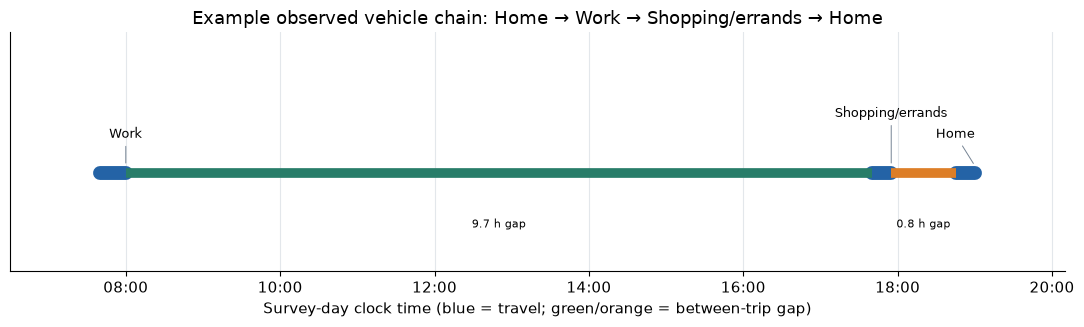

- This representative chain meets the explicit consistency and typical-distance criteria above.
- Only internal gaps are shown; no parking duration is asserted before its first leg or after its final leg.

In [12]:
preferred = "Home → Work → Shopping/errands → Home"
figure_label = preferred if preferred in examples else "Home → Work → Home"
g = examples[figure_label]
fig, ax = plt.subplots(figsize=(11, 3.4))
for i, (_, leg) in enumerate(g.iterrows()):
    ax.plot([float(leg.survey_start_min), float(leg.survey_end_min)], [1,1],
            color=BLUE, lw=10, solid_capstyle="round")
    ax.annotate(purpose_group(leg.WHYTO),
                xy=(float(leg.survey_end_min), 1.02),
                xytext=(0, 18 + 15*(i%2)), textcoords="offset points",
                ha="right" if i==len(g)-1 else "center", va="bottom", fontsize=9,
                arrowprops={"arrowstyle":"-", "color":GREY, "lw":.7})
gap_subset = parking.loc[parking.VEHCASEID.eq(g.iloc[0].VEHCASEID)]
for _, gap in gap_subset.iterrows():
    ax.plot([float(gap.parking_start_min), float(gap.parking_end_min)], [1,1],
            color=GREEN if gap.destination_group in {"Home","Work"} else ORANGE,
            lw=7, solid_capstyle="butt")
    center = (float(gap.parking_start_min)+float(gap.parking_end_min))/2
    ax.text(center, .87, f"{gap.parking_duration_min/60:.1f} h gap",
            ha="center", va="top", fontsize=8)
ax.set_xlim(max(240,float(g.survey_start_min.min())-70),
            min(1680,float(g.survey_end_min.max())+70))
ticks = np.arange(240,1681,120)
ticks = ticks[(ticks>=ax.get_xlim()[0]) & (ticks<=ax.get_xlim()[1])]
ax.set_xticks(ticks,[clock(t) for t in ticks])
ax.set_yticks([])
ax.set_ylim(.72,1.40)
ax.grid(axis="x",color="#e3e7eb")
ax.set(title=f"Example observed vehicle chain: {figure_label}",
       xlabel="Survey-day clock time (blue = travel; green/orange = between-trip gap)")
fig_chain = save_show(fig, "04_representative_vehicle_chain.png")
display(Markdown(
    "- This representative chain meets the explicit consistency and typical-distance criteria above.\n"
    "- Only internal gaps are shown; no parking duration is asserted before its first "
    "leg or after its final leg."
))



## 9. Reproducible interim exports

Export **all 19,673 conflict-free candidate legs**, including purpose-inconsistent
chains with flags, and **all consecutive-leg gaps**, including those ineligible for
parking summaries. No raw file is modified and no processed/final dataset is made.
The schema and safe use of these files are documented in
`docs/methodology/vehicle_trip_chain_schema.md`. Interim CSVs are Git-ignored.

In [13]:
leg_fields = ["HOUSEID","VEHCASEID","VEHID","PERSONID","TDCASEID","SEQ_TRIPID",
              "TRAVDAY","TDAYDATE","vehicle_leg_index","STRTTIME","ENDTIME",
              "start_min","end_min","survey_start_min","survey_end_min",
              "crosses_midnight","trip_duration_min","trip_distance_miles",
              "WHYFROM","WHYTO","origin_group","destination_group",
              "TRPTRANS","travel_mode_label","WTTRDFIN","DWELTIME",
              "continuity_to_next","chain_status","begins_home","ends_home"]
gap_fields = ["HOUSEID","VEHCASEID","TDCASEID","next_TDCASEID","PERSONID",
              "next_PERSONID","WHYTO","next_WHYFROM","destination_group",
              "parking_start_min","parking_end_min","parking_start_clock",
              "parking_end_clock","parking_duration_min","continuity_to_next",
              "chain_status","same_driver","within_survey_window",
              "analysis_eligible","DWELTIME","dwell_valid_min","gap_minus_dwell_min"]
leg_path = interim_dir / "vehicle_trip_chains.csv"
gap_path = interim_dir / "vehicle_parking_intervals.csv"
legs[leg_fields].to_csv(leg_path,index=False)
parking[gap_fields].to_csv(gap_path,index=False)
print(f"Wrote {len(legs):,} candidate legs to {leg_path.relative_to(root)}")
print(f"Wrote {len(parking):,} flagged consecutive-leg gaps to {gap_path.relative_to(root)}")



Wrote 19,673 candidate legs to data\interim\vehicle_trip_chains.csv
Wrote 12,799 flagged consecutive-leg gaps to data\interim\vehicle_parking_intervals.csv


## 10. Interpretation and limits

The chain sample is a defensible **candidate** input to a later simple EV
energy/SOC study *conditional on the retained filters and flags*. It is not a
proven complete vehicle trajectory: person-trip reports can duplicate physical
movements; conflicting vehicle-days are held out; missing trips and changes of
driver are possible; activity-purpose continuity is not geographic continuity;
and the survey supplies one 04:00–04:00 day without exact public calendar date.
The final home arrival has no known overnight parking length. `DWELTIME` remains
person destination dwell, not measured vehicle parking. None of these records
reveal charger access or charging behaviour. Trip weights cannot simply be
applied to derived vehicle-day/gap statistics.

In [14]:
print(f"RECONSTRUCTED: {len(vehicle_day):,} candidate vehicle chains / {len(legs):,} legs")
print(f"CONTINUITY: {int(multi.chain_status.eq('complete').sum()):,}/{len(multi):,} multi-leg chains "
      f"({100*multi.chain_status.eq('complete').mean():.1f}%) complete; "
      f"{int(multi.mismatch.gt(0).sum()):,} mismatched; "
      f"{int(vehicle_day.chain_status.eq('single_leg').sum()):,} single-leg untestable")
print(f"EXCLUDED: {len(invalid)} invalid candidate rows; {len(conflict_ids)} conflicted vehicle-days "
      f"({len(same_start_ids)} duplicate-start, {len(overlap_ids)} other overlap), "
      f"containing {len(held_out)} valid rows")
print(f"PARKING: {len(parking):,} observed internal gaps, {len(eligible):,} eligible "
      "purpose-continuous within-window gaps")
print("PARKING STATS BY DESTINATION (raw sample):")
print(parking_stats.round(1).to_string())
print(f"HOME/WORK: median first home departure {timing.loc['First departure from home','median clock']}; "
      f"median final home return {timing.loc['Final observed return home','median clock']}; "
      f"median work arrival {timing.loc['Arrival at non-home work','median clock']}; "
      f"median work departure {timing.loc['Departure from non-home work','median clock']}")
print(f"DWELTIME: {len(both):,} eligible comparisons; median absolute gap difference "
      f"{comparison.loc['All eligible pairs','median absolute difference (min)']:.1f} min; "
      f"exact {comparison.loc['All eligible pairs','exact match (%)']:.1f}%")
print("LIMITS: person-trip representation, purpose not location, incomplete day, no overnight duration")
print("FIGURES:")
for path in [fig_parking, fig_start, fig_trips, fig_chain]:
    print(" -", path.relative_to(root).as_posix())
print("SUITABILITY: conditional candidate mobility input; use continuity and interval flags, "
      "not as complete national vehicle trajectories")


RECONSTRUCTED: 6,874 candidate vehicle chains / 19,673 legs
CONTINUITY: 6,227/6,410 multi-leg chains (97.1%) complete; 181 mismatched; 464 single-leg untestable
EXCLUDED: 9 invalid candidate rows; 69 conflicted vehicle-days (59 duplicate-start, 10 other overlap), containing 385 valid rows
PARKING: 12,799 observed internal gaps, 12,159 eligible purpose-continuous within-window gaps
PARKING STATS BY DESTINATION (raw sample):
                   intervals  median (h)  p25 (h)  p75 (h)  p90 (h)  >1 h (%)  >2 h (%)  >4 h (%)
destination_group                                                                                
Home                  1351.0         2.2      0.9      4.4      7.2      69.8      52.6      28.3
Work                  2198.0         8.2      5.3      9.2     10.4      95.5      91.9      82.0
Shopping/errands      3287.0         0.5      0.2      0.8      1.4      18.0       4.3       1.2
Social/recreation     1481.0         1.8      1.0      3.0      4.5      74.9      